Atividade1

In [31]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80)

# data (as pandas dataframes)
X = optical_recognition_of_handwritten_digits.data.features
y = optical_recognition_of_handwritten_digits.data.targets

# metadata
print(optical_recognition_of_handwritten_digits.metadata)

# variable information
print(optical_recognition_of_handwritten_digits.variables)


{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

ATIVIDADE 2

In [18]:

import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

# Modelo
modelo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

# Treino
modelo.fit(X_train, y_train)

# Guardar modelo e dados de teste
joblib.dump(modelo, 'modelo_digits.pkl')
joblib.dump((X_test, y_test), 'dados_teste.pkl')

print('Modelo treinado e guardado com sucesso.')

Modelo treinado e guardado com sucesso.


Atividade3

Accuracy: 0.9732888146911519

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.91      0.95      0.93        61
           2       1.00      1.00      1.00        59
           3       0.97      1.00      0.98        61
           4       0.98      0.98      0.98        60
           5       1.00      0.97      0.98        61
           6       1.00      0.98      0.99        60
           7       1.00      1.00      1.00        60
           8       0.91      0.86      0.88        58
           9       0.97      0.98      0.98        60

    accuracy                           0.97       599
   macro avg       0.97      0.97      0.97       599
weighted avg       0.97      0.97      0.97       599

[[59  0  0  0  0  0  0  0  0  0]
 [ 0 58  0  0  1  0  0  0  2  0]
 [ 0  0 59  0  0  0  0  0  0  0]
 [ 0  0  0 61  0  0  0  0  0  0]
 [ 0  0  0  0 59  0  0  0  1  0]
 [ 0  0  0  0  0 59  0

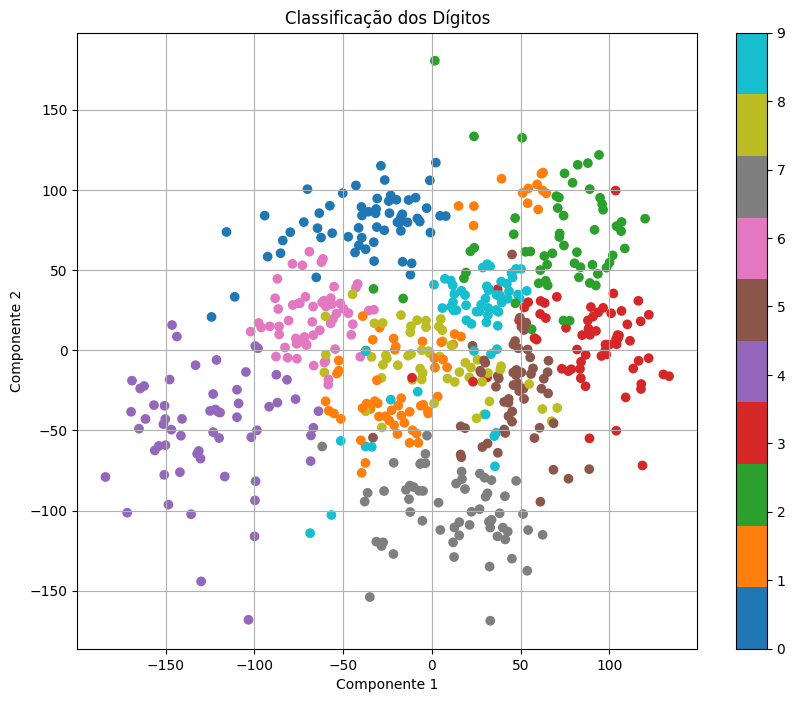

Valor real: 3
Predição: 3


In [20]:
import joblib

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

modelo_carregado = joblib.load('modelo_digits.pkl')

# Carregar dados de teste
X_test, y_test = joblib.load('dados_teste.pkl')

# Predições\\
y_pred = modelo_carregado.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)

# Relatório
print('''
Classification Report:
''')
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Representação gráfica
nca_vis = make_pipeline(
    StandardScaler(),
    NeighborhoodComponentsAnalysis(n_components=2, random_state=42)
)

X_test_nca = nca_vis.fit_transform(X_test, y_test)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_test_nca[:,0],
    X_test_nca[:,1],
    c=y_pred,
    cmap='tab10'
)

plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Classificação dos Dígitos')

plt.colorbar(scatter)
plt.grid(True)
plt.show()

# Predição de exemplo
amostra = X_test[0].reshape(1, -1)

print('Valor real:', y_test[0])
print('Predição:', modelo_carregado.predict(amostra)[0])